Deklarasi Library dan Membaca Data dalam Folder Google Drive

In [ ]:
!pip install mne

In [ ]:
import os
import glob
import scipy.io
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import mne
from scipy.signal import welch
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, accuracy_score

folder_path = '/content/drive/MyDrive/Motoric Imagery'
file_list = glob.glob(os.path.join(folder_path, "*.mat"))
results_log = []

Visualisasi Data Raw

In [ ]:
sample_file = file_list[0]
print(f"Sedang memvisualisasikan file: {os.path.basename(sample_file)}")

mat = scipy.io.loadmat(sample_file)
raw_data = mat['EEGDATA'] # [Channel, Time, Trial]
labels = mat['LABELS'].flatten()
sfreq = 256

#Transpose ke [Trial, Channel, Time]
X_epochs = np.transpose(raw_data, (2, 0, 1))

ch_idx_plot = 0
trial_idx_plot = 5

Sedang memvisualisasikan file: SubA_5chan_3LRF.mat


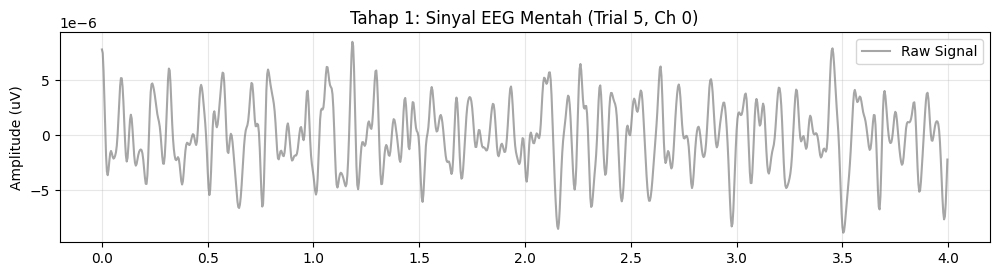

In [ ]:
plt.figure(figsize=(12, 6))

#Plot Sinyal Raw
#Ambil data 1 trial, 1 channel
signal_raw = X_epochs[trial_idx_plot, ch_idx_plot, :]
time_axis = np.arange(len(signal_raw)) / sfreq

plt.subplot(2, 1, 1)
plt.plot(time_axis, signal_raw, color='gray', alpha=0.7, label='Raw Signal')
plt.title(f'Tahap 1: Sinyal EEG Mentah (Trial {trial_idx_plot}, Ch {ch_idx_plot})')
plt.ylabel('Amplitude (uV)')
plt.legend()
plt.grid(True, alpha=0.3)

Filter BPF 4 - 30 Hz

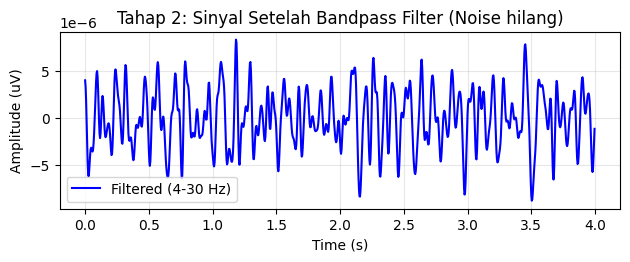

In [ ]:
#Melakukan Filtering (4-30 Hz)
info = mne.create_info(ch_names=X_epochs.shape[1], sfreq=sfreq, ch_types='eeg')
epochs_mne = mne.EpochsArray(X_epochs, info, verbose=False)
epochs_mne.filter(l_freq=4.0, h_freq=30.0, verbose=False) # Proses Filter

signal_filtered = epochs_mne.get_data()[trial_idx_plot, ch_idx_plot, :]

plt.subplot(2, 1, 2)
plt.plot(time_axis, signal_filtered, color='blue', label='Filtered (4-30 Hz)')
plt.title('Tahap 2: Sinyal Setelah Bandpass Filter (Noise hilang)')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude (uV)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Ekstraksi Fitur menggunakan PSD (Power Spectral Density)

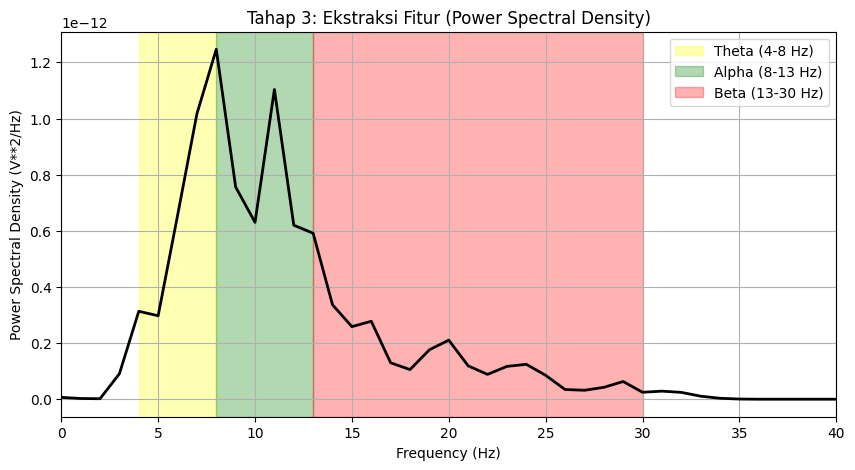

In [ ]:
freqs, psd = welch(signal_filtered, fs=sfreq, nperseg=256)

plt.figure(figsize=(10, 5))
plt.plot(freqs, psd, color='black', lw=2)
plt.title('Tahap 3: Ekstraksi Fitur (Power Spectral Density)')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Power Spectral Density (V**2/Hz)')
plt.xlim(0, 40) # Zoom di area 0-40 Hz

# Arsir Area Fitur yang kita ambil
# Theta (4-8), Alpha (8-13), Beta (13-30)
plt.axvspan(4, 8, color='yellow', alpha=0.3, label='Theta (4-8 Hz)')
plt.axvspan(8, 13, color='green', alpha=0.3, label='Alpha (8-13 Hz)')
plt.axvspan(13, 30, color='red', alpha=0.3, label='Beta (13-30 Hz)')

plt.legend()
plt.grid(True)
plt.show()

Box Scatter Plot

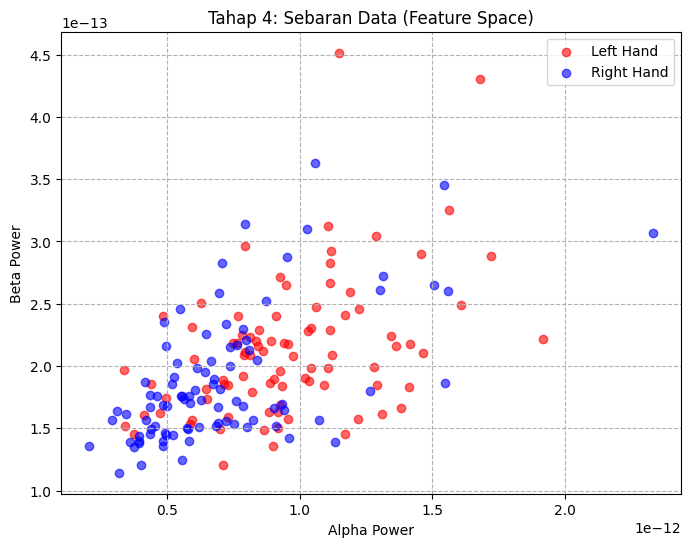

In [ ]:
def get_simple_features(epochs_data):
    feats = []
    for trial in epochs_data:
        # Ambil channel 0 saja sebagai contoh visualisasi
        f, p = welch(trial[0, :], fs=sfreq, nperseg=256)
        alpha = np.mean(p[(f >= 8) & (f <= 13)])
        beta = np.mean(p[(f >= 13) & (f <= 30)])
        feats.append([alpha, beta])
    return np.array(feats)

X_feats_simple = get_simple_features(epochs_mne.get_data())

# Plot Scatter
plt.figure(figsize=(8, 6))
# Ambil index kelas 1 dan 2 (Left vs Right)
idx_left = labels == 1
idx_right = labels == 2

plt.scatter(X_feats_simple[idx_left, 0], X_feats_simple[idx_left, 1],
            color='red', label='Left Hand', alpha=0.6)
plt.scatter(X_feats_simple[idx_right, 0], X_feats_simple[idx_right, 1],
            color='blue', label='Right Hand', alpha=0.6)

plt.title('Tahap 4: Sebaran Data (Feature Space)')
plt.xlabel('Alpha Power')
plt.ylabel('Beta Power')
plt.legend()
plt.grid(True, linestyle='--')
plt.show()

Machine Learning (Confusion Matrix)

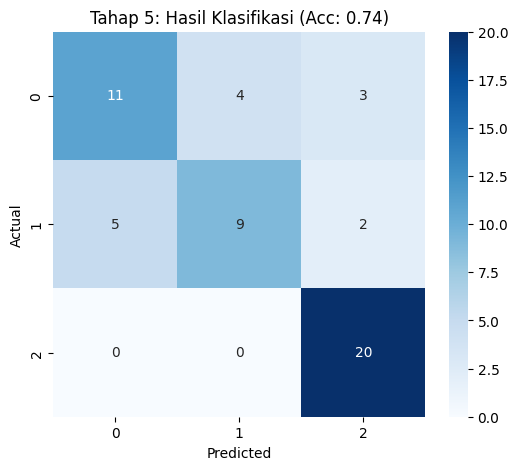

In [ ]:
def extract_full_features(data):
    features = []
    for trial in data:
        trial_feats = []
        for ch in trial:
            f, p = welch(ch, fs=sfreq, nperseg=256)
            alpha = np.mean(p[(f >= 8) & (f <= 13)])
            beta = np.mean(p[(f >= 13) & (f <= 30)])
            trial_feats.extend([alpha, beta])
        features.append(trial_feats)
    return np.array(features)

X_full = extract_full_features(epochs_mne.get_data())
y_full = labels

# Split & Train
X_train, X_test, y_train, y_test = train_test_split(X_full, y_full, test_size=0.2, random_state=42)
clf = RandomForestClassifier(n_estimators=100)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

# Plot Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title(f'Tahap 5: Hasil Klasifikasi (Acc: {accuracy_score(y_test, y_pred):.2f})')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()